# Exercise 1

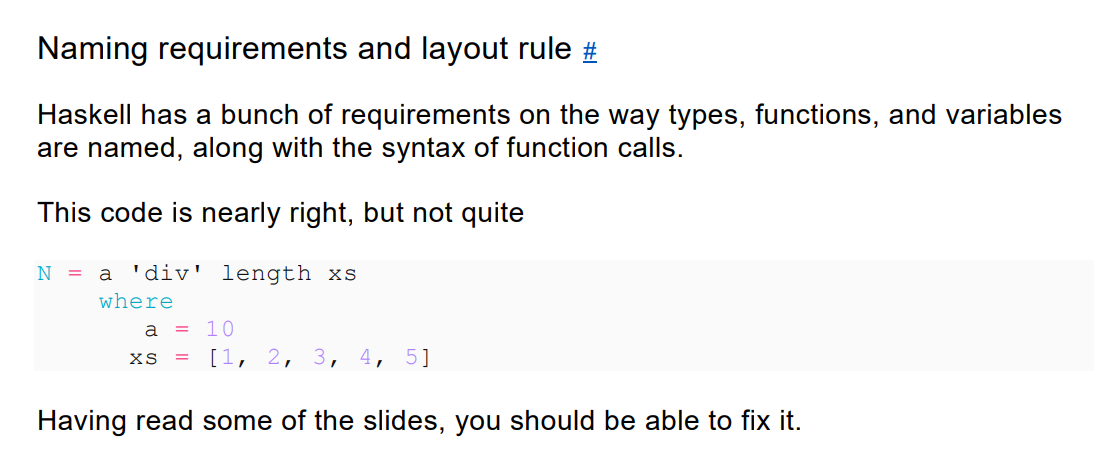

In [1]:
n = a `div` length xs
    where
        a = 10
        xs = [1, 2, 3, 4, 5]

```haskell
-- The badly formatted code
-- N = a 'div' length xs
--     where
--        a = 10
--       xs = [1, 2, 3, 4, 5]
-- Needs a few changes
-- First, identifiers need to start with a lower-case letter, so
-- replace N with n.
-- Second, the way to write infix functions is to use backticks ` (not
-- quotes '), so replace 'div' with `div`.
-- Finally, we need to align the start of the definitions in the where
-- clause (remember the alignment rule)
-- We should also type annotate, since length returns an Int, this
-- value has type Int.
n :: Int
n = a `div` length xs
    where
       a = 10
       xs = [1, 2, 3, 4, 5]
```

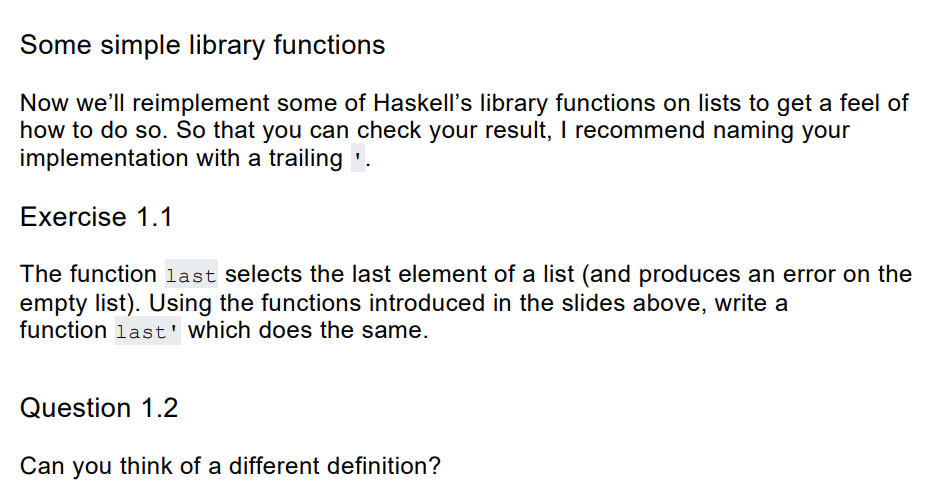

In [2]:
last' :: [a] -> a
last' xs = xs !! (length xs - 1)

In [3]:
last' [1,2,3,4,5]

5

In [4]:
last' []

: 

In [5]:
last'' :: [a] -> a
last'' xs = head (reverse xs)

Line 2: Use last
Found:
head (reverse xs)
Why not:
last xs

In [6]:
last'' [1,2,3,4,5]

5

In [7]:
last'' []

: 

```haskell
-- Here's one way, compute the length of the list, subtract 1 (since
-- everything is zero-indexed) and use the list indexing operator (!!)
-- to get it out.
-- This approach needs to traverse the list twice, once to compute the
-- length and the a second time to index it.
last' :: [a] -> a
last' xs = xs !! (length xs - 1)

-- We can also note that the last element of the list is the first (or
-- head) element of the reversed list. This only traverses the list once.
last'' :: [a] -> a
last'' xs = head (reverse xs)

-- Or, we can write in "pointfree" style, this is the same as the
-- previous definition but now we don't have to explicitly refer to
-- the list xs by name. The (.) operator is function composition.
-- See this discussion for more detail
-- https://github.com/wenceorg/comp2221/discussions/14
last''' :: [a] -> a
last''' = head . reverse
```

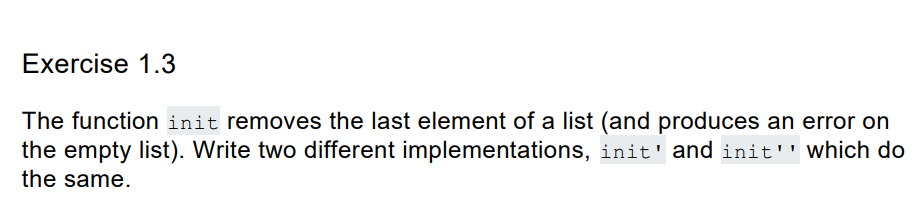

In [8]:
init' :: [a] -> [a]
init' xs = take (length xs - 1) xs

In [9]:
init' [1,2,3,4,5]

[1,2,3,4]

In [10]:
init'' :: [a] -> [a]
init'' xs = reverse (tail (reverse xs))

Line 2: Use init
Found:
reverse (tail (reverse xs))
Why not:
init xs

In [11]:
init'' [1,2,3,4,5]

[1,2,3,4]

```haskell
-- To drop the last element (which init does) we can do the same thing
-- as before, figuring out the length of the list and using `take` to
-- take the correct number of items.
-- This approach traverses the list twice
init' :: [a] -> [a]
init' xs = take (length xs - 1) xs

-- Again, we can use reverse and tail to do things. This approach now
-- also traverses the list twice.
init'' :: [a] -> [a]
init'' xs = reverse (tail (reverse xs))

-- A pointfree version is now like so.
init''' :: [a] -> [a]
init''' = reverse . tail . reverse

-- If we want to avoid multiple traversals, we have to recurse over
-- the list by hand. The standard library definition does that like so
initOnce :: [a] -> [a]
initOnce [x]                =  []
initOnce (x:xs)             =  x : initOnce xs
initOnce []                 =  undefined
```

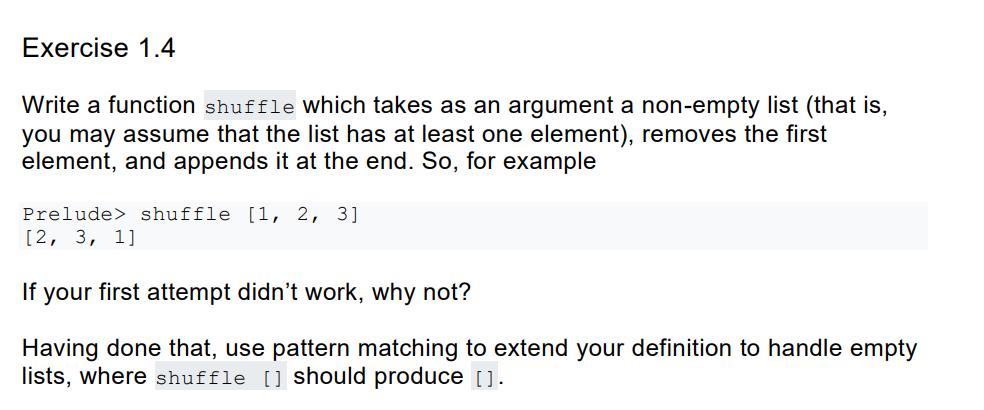

In [12]:
shuffle :: [a] -> [a]
shuffle [] = []
shuffle (x:xs) = xs ++ [x]

In [13]:
shuffle [1,2,3]

[2,3,1]

In [14]:
shuffle []

[]

```haskell
-- To do this, we pattern match and destructure the list into its head
-- and tail (x:xs). Then we move the head to the tail by using (++)
-- "append". You might have tried `xs ++ x` first, which would fail
-- because x :: a, not [a], and (++) :: [a] -> [a] -> [a]. That is,
-- append takes two lists and produces a new one.
shuffle :: [a] -> [a]
shuffle (x:xs) = xs ++ [x]
-- This pattern match is necessary so that shuffle [] produces [].
shuffle [] = []
```

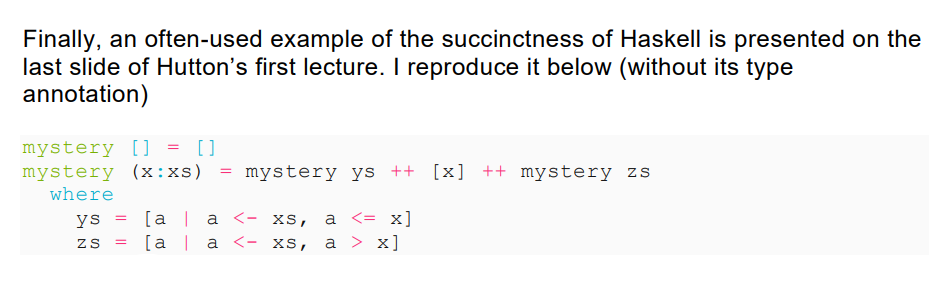
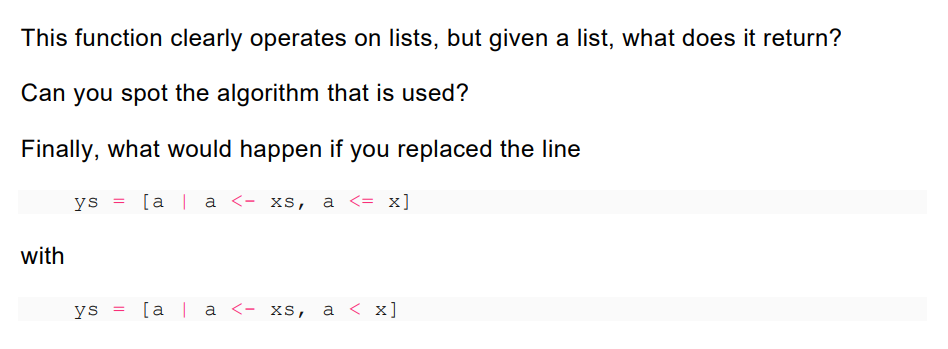

It returns the list sorted such that the elements less than or equal to the first element are at the front of the list, those larger than the first element are at the end, and the first element is between these two sublists. The algorithm used is from quick sort.

Replacing the line would mean that any duplicates of the first element are removed. 

```haskell
-- This function implements quicksort (with a rather bad pivot
-- selection).
-- See this discussion
-- https://github.com/wenceorg/comp2221/discussions/7
-- for more details.
mystery [] = []
mystery (x:xs) = mystery ys ++ [x] ++ mystery zs
  where
    ys = [a | a <- xs, a <= x]
    zs = [b | b <- xs, b > x]

-- If we were to replace a <= x by a < x, then the sorting also
-- removes duplicates.
```

# Exercise 2

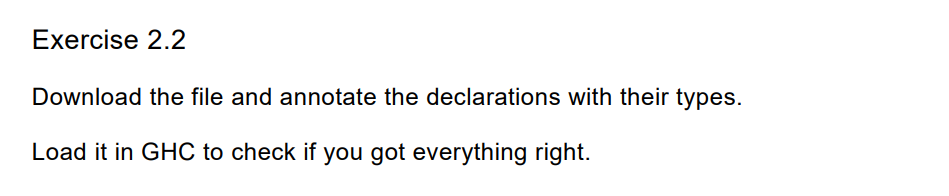

In [15]:
x1 :: [Char]
x1 = ['a', 'b', 'c']

x2 :: (Char, Char, Char)
x2 = ('a', 'b', 'c')

x3 :: [(Bool, Int)]
x3 = [(False, 0), (True, 10)]

x4 :: ([Bool], [Int])
x4 = ([False, True], [0, 1])

x5 :: [[a]->[a]]
x5 = [tail, reverse, init]

swap :: (a, b) -> (b, a) 
swap (x, y) = (y, x)

pair :: a -> b -> (a,b)
pair x y = (x, y)

-- Correction: square :: Num a => a -> a
square :: Floating a => a -> a
square x = x*x

palindrome :: Eq a => [a] -> Bool
palindrome xs = xs == reverse xs

twice :: (a -> a) -> a -> a
twice f x = f (f x)

```haskell
x1 :: [Char]
x1 = ['a', 'b', 'c']

x2 :: (Char, Char, Char)
x2 = ('a', 'b', 'c')

-- This is a valid option
x3 :: [(Bool, Int)]
-- At the REPL
-- GHC infers the constrained polymorphic type
-- Num a => [(Bool, a)]
-- This means that the second entry in the tuple is a number. Bare
-- numbers like this are inferred to be polymorphic until such time as
-- they are used in a context where a concrete type is required.
-- When the module is loaded it infers [(Bool, Integer)]. I suppose
-- because the compilation needs to figure out how much storage is
-- required.
x3 = [(False, 0), (True, 10)]

-- This time we have (so tuple on the outside, list on the inside).
-- Again Num a => ([Bool], [a]) is also fine
x4 :: ([Bool], [Int])
x4 = ([False, True], [0, 1])

-- All of these are functions from [a] -> [a], so this has type list
-- of [a] -> [a]. Notice that we can't put arbitrary functions in
-- here, we can't additionally have head :: [a] -> a, because it has
-- the wrong type.
x5 :: [[a] -> [a]]
x5 = [tail, reverse, init]

-- The only thing we know about x and y is that they may have
-- different polymorphic types so this is
swap :: (a, b) -> (b, a)
swap (x, y) = (y, x)

-- For pair, we take the arguments one at a time (curried)
pair :: a -> b -> (a, b)
pair x y = (x, y)

-- This one is also a constrained polymorphic function
-- Multiplication requires that the value is a numeric type, so we
-- have
square :: Num a => a -> a
square x = x*x

-- This one also has a constraint, this time, that the elements of the
-- list are comparable
palindrome :: Eq a => [a] -> Bool
palindrome xs = xs == reverse xs

-- We determine from the use of `f` on the right hand side that it is
-- a function of one argument. We don't know any more, so it must be
-- polymorphic.
-- This time we have to parenthesise the first (a -> a) to indicate
-- the the first argument is a function type.
twice :: (a -> a) -> a -> a
twice f x = f (f x)
```

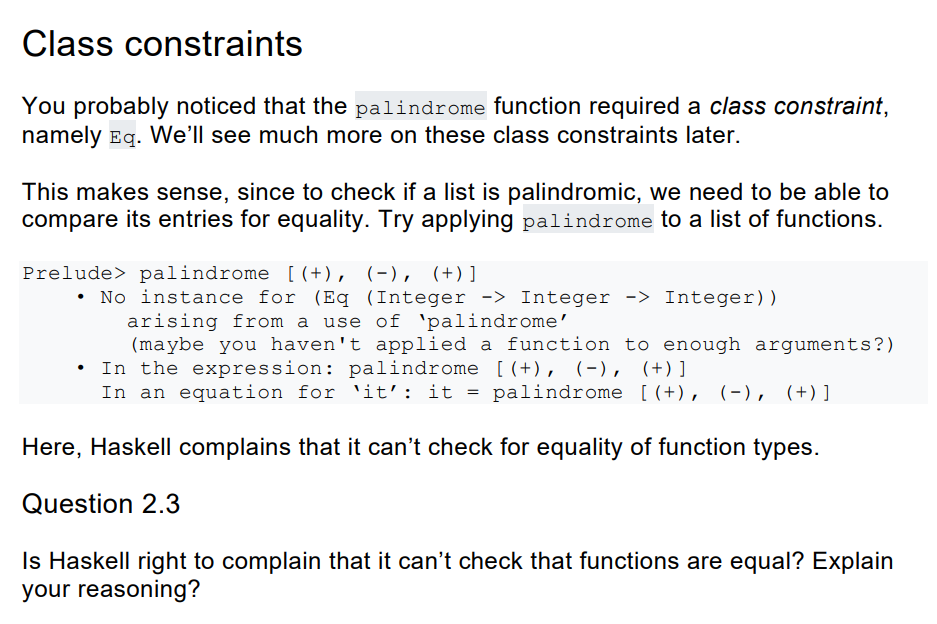
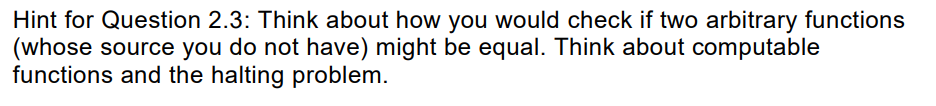

Yes. To check that two functions are equal, you may have to enumerate every possible input and confirm that they have identical results. There can be infinite inputs to a function, which would result in the equality check never halting. 

```haskell
-- Is Haskell right to complain that it can’t check that functions are
-- equal? Explain your reasoning?
--
-- I think Haskell is correct to complain. Although we can look at
-- some source code and reason about the functions it is quite
-- difficult for us. Let us think about what it would mean for two
-- functions to be equal: it must mean that whereever we see the use
-- of the first function f, we can replace it with the second function
-- g. In a pure language like Haskell, this is a valid substitution to
-- make (due to referential transparency
-- https://en.wikipedia.org/wiki/Referential_transparency).
-- If I only have the functions as a black box, then the only way I
-- can determine if they are equal is to check if for every input to
-- f, I get the same answer if I provide it as an input to g.
-- This already is a problem, since think of a simple function that
-- squares its argument. I can't check all inputs, since there are an
-- infinite number of integers.
--
-- Furthermore, the only functions we have a chance of checking is
-- ones that are guaranteed to return an answer at all. That is both f
-- and g must be computable
-- (https://en.wikipedia.org/wiki/Computable_function). In Haskell, I
-- can write functions which don't return: we might say that two
-- functions are equivalent if they both don't return but determining
-- if a function returns is equivalent (in a Turing complete language)
-- to solving the halting problem
-- (https://en.wikipedia.org/wiki/Halting_problem) which Turing proved
-- is not possible.
-- That's a long way of saying that Haskell is right to complain!
```

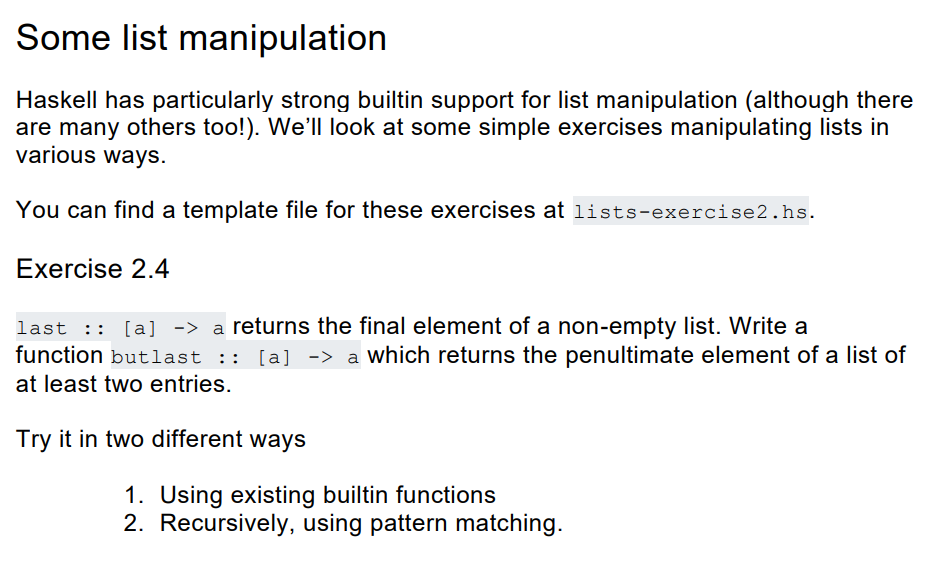


In [16]:
butlast' :: [a] -> a
butlast' xs = xs !! (length xs - 2)

butlast' [1,2,3]

2

In [17]:
butlast'' :: [a] -> a
butlast'' [x,y] = x
butlast'' (x:y:xs) = butlast'' (y:xs)

butlast'' [1,2,3]

2

```haskell
-- Now some list manipulation, we were asked to write butlast which
-- returns the penultimate element of a list of at least two entries

-- First with builtin functions, we notice that if we reverse a list,
-- take its tail and then take the head of that, we get the
-- penultimate element. This will error if the list does not contain
-- two or more elements.
butlast :: [a] -> a
butlast xs = head (tail (reverse xs))

-- We can also write this in pointfree style
-- See https://github.com/wenceorg/comp2221/discussions/14 for more
-- information
butlast' :: [a] -> a
butlast' = head . tail . reverse

-- We were also asked to write this with pattern matching and
-- recursion, let's have a go
butlast'' :: [a] -> a
-- If we have a two-element list, then we are at the base case and can
-- return the first element
butlast'' [x, _] = x
-- If we have a non-empty-list of more than two elements then let's
-- recurse. This pattern actually matches the single element list [_],
-- for which we have said the answer is undefined, but the recursion
-- then ends up calling butlast'' [] which is cleaned up by the next
-- pattern.
-- If we wanted to explicitly handle the single-element case, we would
-- add a pattern butlast'' [_] = undefined
butlast'' (x:xs) = butlast'' xs
-- Finally we need to handle the patterns that we haven't matched yet
-- This is only the empty list, for which we are undefined
-- We can match on a hole here if we like
butlast'' _ = undefined

-- Both of these implementations walk down the list once, and so they
-- are both O(n) in the length of the list. That is, the amount of
-- time it takes grows linearly with the length.
```

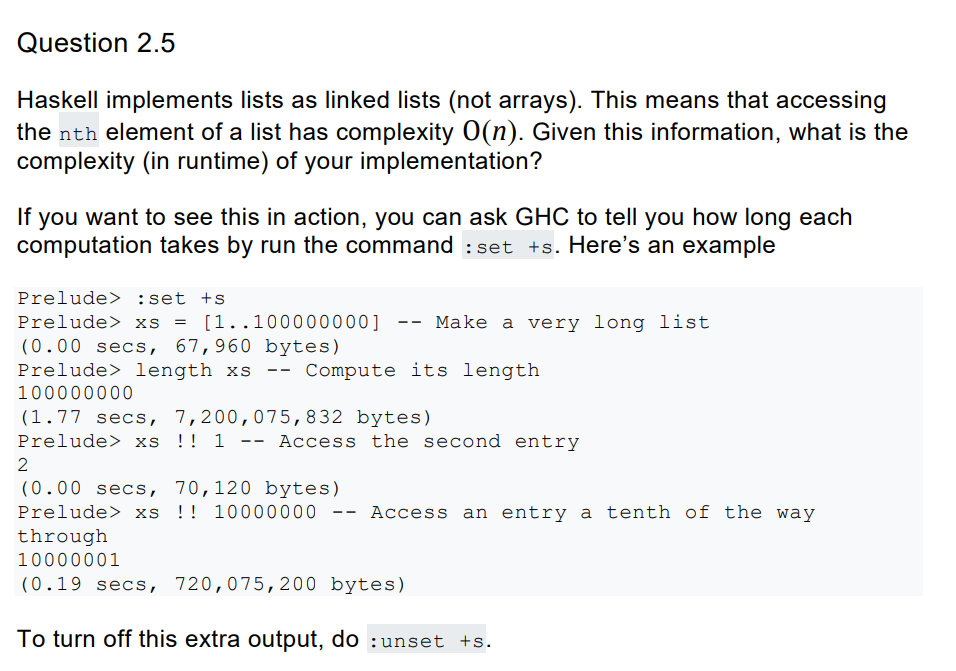

My first implementation
```haskell
butlast' :: [a] -> a
butlast' xs = xs !! (length xs - 2)
```
has runtime complexity `O(n)`, since traversing the list has runtime `n`, as does indexing, so the total runtime is `O(2n)` = `O(n)`. 

My second implementation 
```haskell
butlast'' :: [a] -> a
butlast'' [x,y] = x
butlast'' (x:y:xs) = butlast'' (y:xs)
```
also has runtime complexity `O(n)`. There can be `n` recursive calls, but each call is `O(1)`. 

```haskell
-- Both of these implementations walk down the list once, and so they
-- are both O(n) in the length of the list. That is, the amount of
-- time it takes grows linearly with the length.
```

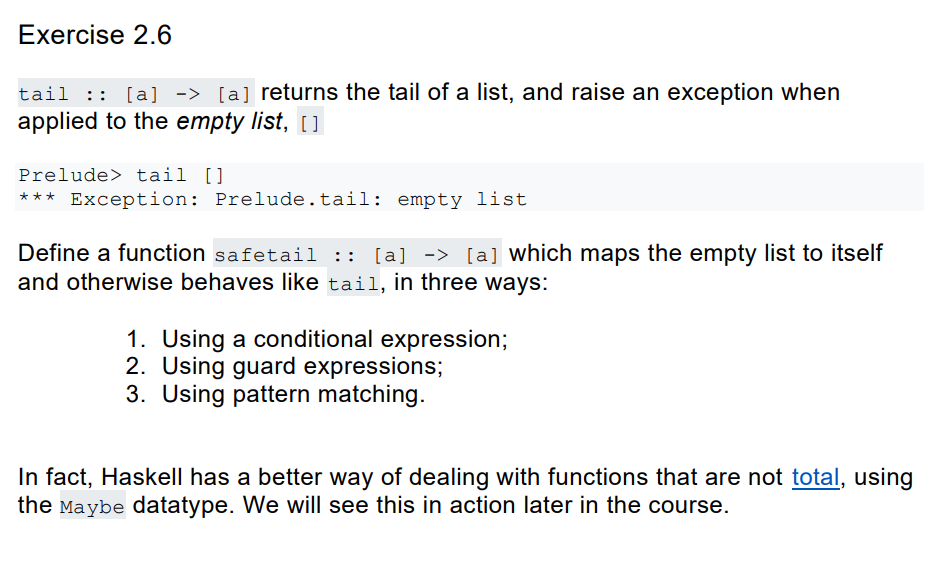

In [18]:
safetail :: Eq a => [a] -> [a]
safetail xs = if xs == [] then [] else tail xs

safetail []
safetail [1,2,3,4]

Line 2: Use null
Found:
xs == []
Why not:
null xs

[]

[2,3,4]

In [19]:
safetail' :: Eq a => [a] -> [a]
safetail' xs
    | xs == [] = []
    | otherwise = tail xs

safetail []
safetail [1,2,3,4]

Line 3: Use null
Found:
xs == []
Why not:
null xs

[]

[2,3,4]

In [20]:
safetail'' :: [a] -> [a]
safetail'' [] = []
safetail'' (x:xs) = xs

safetail []
safetail [1,2,3,4]

[]

[2,3,4]

```haskell
-- Finally we are to write safetail in three different ways
-- First with conditionals
-- This is reasonably straightforward. The only thing to note is that
-- we should use the function null :: [a] -> Bool to check for the
-- input list being empty. DO NOT use (length xs == 0) for checking
-- the emptiness of a list, since this always has to traverse to the
-- end of the list. It is inefficient for finite-sized lists, and does
-- not terminate for infinite lists.
-- That is, (null [1..]) returns False immediately,
-- whereas (length [1..] == 0) never returns.
safetail :: [a] -> [a]
safetail xs = if null xs then [] else tail xs

-- With guard expressions we have a similar story
-- Again, note the use of null to check emptiness
safetail' :: [a] -> [a]
safetail' xs
  | null xs   = []
  | otherwise = tail xs


-- Finally with pattern matching
safetail'' :: [a] -> [a]
safetail'' [] = []
-- We can destructure here
-- The other option would be
-- safetail'' xs = tail xs
-- In that case, we would need to make sure that this pattern comes
-- second.
safetail'' (_:xs) = xs

-- Finally let's look at another way of doing a guard-like approach,
-- using a case expression. This is a slightly desugared way of doing
-- pattern matching, but where we can call a function and match on the
-- result. This not so useful here, the difference is that the case is
-- an _expression_ so we can use it inside a larger statement if we
-- like. For a little bit more description, see
-- http://learnyouahaskell.com/syntax-in-functions
safetail''' :: [a] -> [a]
safetail''' xs = case null xs of
                   True -> []
                   _ -> tail xs
```